# 04 - Compression Tradeoffs: Size vs Accuracy vs Latency

The first three notebooks asked *can distillation make a small student match a big teacher?* This one asks the deployment question: **given a size or latency budget, what accuracy can you actually buy, and does distillation move that curve?**

We hold one teacher fixed and sweep a family of student sizes. Each student is trained two ways -- from scratch, and distilled from the teacher -- so we can read the *lift* distillation provides at every point on the size axis. Then we time inference so accuracy can be plotted against the thing a serving system really cares about: latency.

Everything runs on CPU in a couple of minutes: 16x16 MNIST, a few thousand examples, a handful of epochs.

## Setup and reproducible data

We resolve `DATA_ROOT` by walking up to the workspace `pyproject.toml`, so the notebook finds the already-downloaded MNIST regardless of the current working directory (`download=False` -- we never hit the network). Images are downscaled to 16x16 and we keep a ~8000/2000 train/test subset to keep every training run short. `torch.manual_seed(0)` makes the whole notebook reproducible.

In [1]:
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

torch.manual_seed(0)
np.random.seed(0)
torch.set_num_threads(max(1, torch.get_num_threads()))

# Resolve DATA_ROOT robustly by walking up to the project pyproject.toml.
_r = Path.cwd()
while not (_r / 'pyproject.toml').exists() and _r != _r.parent:
    _r = _r.parent
DATA_ROOT = str(_r / 'data')
print('DATA_ROOT =', DATA_ROOT)

IMG = 16          # downscaled side length
N_TRAIN = 8000
N_TEST = 2000
device = torch.device('cpu')

DATA_ROOT = C:\Users\abero\dev\applied_learning\data


Load MNIST once, downscale, and slice fixed subsets into in-memory tensors. Working from tensors (rather than re-decoding images each epoch) keeps the training loops fast and deterministic.

In [2]:
tfm = transforms.Compose([
    transforms.Resize((IMG, IMG)),
    transforms.ToTensor(),  # [0,1], shape (1, IMG, IMG)
])

train_full = datasets.MNIST(root=DATA_ROOT, train=True, download=False, transform=tfm)
test_full = datasets.MNIST(root=DATA_ROOT, train=False, download=False, transform=tfm)


def stack(ds, n):
    xs, ys = [], []
    for i in range(n):
        x, y = ds[i]
        xs.append(x)
        ys.append(y)
    return torch.stack(xs), torch.tensor(ys)


Xtr, Ytr = stack(train_full, N_TRAIN)
Xte, Yte = stack(test_full, N_TEST)
print('train', tuple(Xtr.shape), 'test', tuple(Xte.shape))

BATCH = 128
train_ds = TensorDataset(Xtr, Ytr)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
test_ds = TensorDataset(Xte, Yte)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

train (8000, 1, 16, 16) test (2000, 1, 16, 16)


## Models: one teacher, a family of students

The **teacher** is a small two-conv CNN -- enough capacity to learn good soft targets on this subset. The **students** are deliberately tiny MLPs parameterised by a single hidden width. Sweeping the width gives us three distinct parameter counts from *tiny* to *small*, which is exactly the size axis we want to plot accuracy against.

In [3]:
class TeacherCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.c1 = nn.Conv2d(1, 32, 3, padding=1)
        self.c2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.c1(x)))  # 16 -> 8
        x = self.pool(F.relu(self.c2(x)))  # 8 -> 4
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


class StudentMLP(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.fc1 = nn.Linear(IMG * IMG, hidden)
        self.fc2 = nn.Linear(hidden, 10)

    def forward(self, x):
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters())


STUDENT_WIDTHS = [8, 24, 64]  # tiny -> small; 3 distinct param counts
for w in STUDENT_WIDTHS:
    print('width', w, '-> params', count_params(StudentMLP(w)))
print('teacher params', count_params(TeacherCNN()))

width 8 -> params 2146
width 24 -> params 6418
width 64 -> params 17098
teacher params 151306


## Training helpers

Two loss modes:

- **Scratch** -- ordinary cross-entropy on the hard labels.
- **Distilled** -- the standard Hinton response/logit objective: a temperature-softened KL term against the teacher's soft targets, blended with the hard-label cross-entropy. The KL term is scaled by `T*T` so its gradient magnitude stays comparable as temperature changes.

Both modes share the same optimizer settings and epoch budget, so the only difference being measured is the *supervision signal*.

**Optimizer note:** students train with SGD + momentum, not Adam. On a task this easy, Adam drives a tiny MLP to its accuracy ceiling so fast that the soft-target regularization has nothing left to add -- scratch and distilled tie. Under plain SGD the soft targets' regularizing effect actually shows up, which is the regime the original distillation results were measured in. The teacher itself is trained with Adam (it just needs to be a strong, fixed source of soft targets).

In [4]:
STUDENT_EPOCHS = 25   # students: SGD needs more passes than Adam
TEACHER_EPOCHS = 15   # teacher: Adam, trained once
T = 4.0               # distillation temperature
ALPHA = 0.5           # weight on the soft-target (distillation) loss


@torch.no_grad()
def accuracy(model):
    model.eval()
    correct = 0
    total = 0
    for xb, yb in test_loader:
        pred = model(xb).argmax(1)
        correct += (pred == yb).sum().item()
        total += yb.numel()
    return correct / total


def _student_opt(model):
    return torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)


def train_scratch(model, epochs=STUDENT_EPOCHS):
    opt = _student_opt(model)
    model.train()
    for _ in range(epochs):
        for xb, yb in train_loader:
            opt.zero_grad()
            loss = F.cross_entropy(model(xb), yb)
            loss.backward()
            opt.step()
    return model


def train_distilled(student, teacher, epochs=STUDENT_EPOCHS, T=T, alpha=ALPHA):
    teacher.eval()
    opt = _student_opt(student)
    student.train()
    for _ in range(epochs):
        for xb, yb in train_loader:
            opt.zero_grad()
            with torch.no_grad():
                t_logits = teacher(xb)
            s_logits = student(xb)
            soft = F.kl_div(
                F.log_softmax(s_logits / T, dim=1),
                F.softmax(t_logits / T, dim=1),
                reduction='batchmean',
            ) * (T * T)
            hard = F.cross_entropy(s_logits, yb)
            loss = alpha * soft + (1.0 - alpha) * hard
            loss.backward()
            opt.step()
    return student

## Step 1 -- train the teacher

The teacher only needs to be a *good enough* source of soft targets. We train it with Adam on the same subset (fast convergence for the big model) and report its test accuracy as the ceiling the students reach toward.

In [5]:
def train_teacher(model, epochs=TEACHER_EPOCHS):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for _ in range(epochs):
        for xb, yb in train_loader:
            opt.zero_grad()
            F.cross_entropy(model(xb), yb).backward()
            opt.step()
    return model


torch.manual_seed(0)
teacher = TeacherCNN()
t0 = time.perf_counter()
train_teacher(teacher)
teacher_acc = accuracy(teacher)
print(f'teacher test accuracy: {teacher_acc:.4f}  '
      f'(trained in {time.perf_counter() - t0:.1f}s)')

teacher test accuracy: 0.9635  (trained in 9.9s)


## Step 2 -- train each student size, scratch vs distilled

For every width we train two fresh students: one from scratch, one distilled from the teacher. We re-seed before each `nn.Module` is built so scratch and distilled start from comparable initialisations and the comparison is about supervision, not lucky weights. We record parameter count and test accuracy for both.

In [6]:
results = []  # one row per width
student_models = {}  # width -> trained distilled student (reused for latency)

for w in STUDENT_WIDTHS:
    torch.manual_seed(0)
    s_scratch = StudentMLP(w)
    train_scratch(s_scratch)
    acc_scratch = accuracy(s_scratch)

    torch.manual_seed(0)
    s_distill = StudentMLP(w)
    train_distilled(s_distill, teacher)
    acc_distill = accuracy(s_distill)

    p = count_params(s_distill)
    student_models[w] = s_distill
    results.append({'width': w, 'params': p,
                    'acc_scratch': acc_scratch, 'acc_distill': acc_distill})
    print(f'width {w:3d} | params {p:6d} | scratch {acc_scratch:.4f} | '
          f'distilled {acc_distill:.4f} | lift {acc_distill - acc_scratch:+.4f}')

width   8 | params   2146 | scratch 0.8525 | distilled 0.8800 | lift +0.0275


width  24 | params   6418 | scratch 0.9160 | distilled 0.9210 | lift +0.0050


width  64 | params  17098 | scratch 0.9350 | distilled 0.9530 | lift +0.0180


## Step 3 -- accuracy vs parameter count

The headline plot. X-axis is parameter count on a **log scale** (sizes span an order of magnitude); two curves trace scratch vs distilled accuracy. The gap between the curves is the value distillation adds. The expected shape: both curves rise with capacity, but the distilled curve sits above the scratch curve, and the gap is **largest for the smallest student** -- exactly where a tiny model most needs the teacher's dark knowledge to make up for missing capacity.

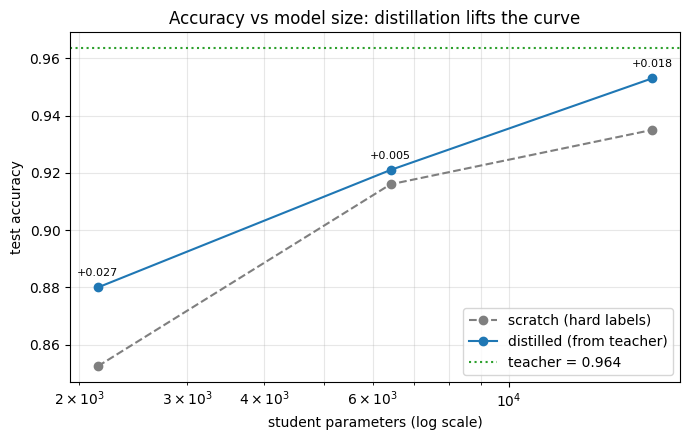

In [7]:
params = [r['params'] for r in results]
acc_s = [r['acc_scratch'] for r in results]
acc_d = [r['acc_distill'] for r in results]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(params, acc_s, 'o--', color='tab:gray', label='scratch (hard labels)')
ax.plot(params, acc_d, 'o-', color='tab:blue', label='distilled (from teacher)')
ax.axhline(teacher_acc, color='tab:green', ls=':', label=f'teacher = {teacher_acc:.3f}')
ax.set_xscale('log')
ax.set_xlabel('student parameters (log scale)')
ax.set_ylabel('test accuracy')
ax.set_title('Accuracy vs model size: distillation lifts the curve')
for r in results:
    ax.annotate(f"+{r['acc_distill'] - r['acc_scratch']:.3f}",
                (r['params'], r['acc_distill']),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
ax.legend(loc='lower right')
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
plt.show()

## Step 4 -- inference latency, the deployment view

Accuracy per parameter is the research view; accuracy per *millisecond* is the serving view. We measure mean latency for one forward pass over a fixed batch: a few warmup passes (to let any lazy allocation settle), then average several timed runs with gradients disabled and the model in `eval()` mode. We time the teacher and every distilled student, then plot accuracy against latency -- the practical Pareto frontier you choose a deployment point from.

In [8]:
@torch.no_grad()
def latency_ms(model, batch, warmup=5, runs=30):
    model.eval()
    for _ in range(warmup):
        model(batch)
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        model(batch)
        times.append((time.perf_counter() - t0) * 1000.0)
    return float(np.mean(times))


bench_batch = Xte[:128]

teacher_lat = latency_ms(teacher, bench_batch)
print(f'teacher: acc {teacher_acc:.4f} | latency {teacher_lat:.3f} ms/batch')

for r in results:
    m = student_models[r['width']]
    r['latency_ms'] = latency_ms(m, bench_batch)
    print(f"width {r['width']:3d}: acc {r['acc_distill']:.4f} | "
          f"latency {r['latency_ms']:.3f} ms/batch")

teacher: acc 0.9635 | latency 2.564 ms/batch
width   8: acc 0.8800 | latency 0.036 ms/batch
width  24: acc 0.9210 | latency 0.047 ms/batch
width  64: acc 0.9530 | latency 0.054 ms/batch


Now plot accuracy vs latency. Each distilled student is a candidate deployment point; the teacher anchors the high-accuracy / high-cost corner. The sweet spot is the point that buys most of the teacher's accuracy for a fraction of its latency.

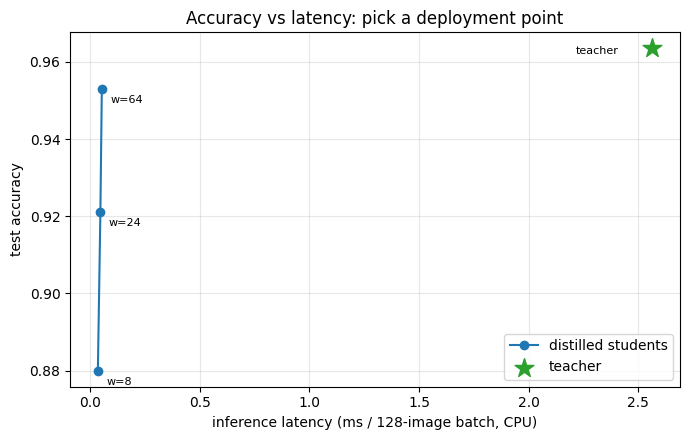

In [9]:
lat_d = [r['latency_ms'] for r in results]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(lat_d, acc_d, 'o-', color='tab:blue', label='distilled students')
for r in results:
    ax.annotate(f"w={r['width']}", (r['latency_ms'], r['acc_distill']),
                textcoords='offset points', xytext=(6, -10), fontsize=8)
ax.scatter([teacher_lat], [teacher_acc], color='tab:green', marker='*',
           s=200, zorder=5, label='teacher')
ax.annotate('teacher', (teacher_lat, teacher_acc),
            textcoords='offset points', xytext=(-55, -4), fontsize=8)
ax.set_xlabel('inference latency (ms / 128-image batch, CPU)')
ax.set_ylabel('test accuracy')
ax.set_title('Accuracy vs latency: pick a deployment point')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Step 5 -- combined numbers and a method-choice cheat sheet

A single table tying the three axes together for every model:

In [10]:
header = f"{'model':<16}{'params':>10}{'test acc':>11}{'latency (ms)':>15}"
print(header)
print('-' * len(header))
print(f"{'teacher CNN':<16}{count_params(teacher):>10}"
      f"{teacher_acc:>11.4f}{teacher_lat:>15.3f}")
for r in results:
    name = f"student w={r['width']}"
    print(f"{name:<16}{r['params']:>10}{r['acc_distill']:>11.4f}"
          f"{r['latency_ms']:>15.3f}")

model               params   test acc   latency (ms)
----------------------------------------------------
teacher CNN         151306     0.9635          2.564
student w=8           2146     0.8800          0.036
student w=24          6418     0.9210          0.047
student w=64         17098     0.9530          0.054


### Response (logit) vs feature distillation -- when to use which

This notebook used **response (logit) distillation** throughout -- the student matches the teacher's softened output probabilities. That is the method built up in [02-logit-distillation-mnist](02-logit-distillation-mnist.ipynb). The alternative, **feature (hint) distillation** -- matching intermediate activations, FitNets-style -- is covered in [03-feature-distillation-fitnets](03-feature-distillation-fitnets.ipynb). Qualitative guidance:

| Aspect | Response / logit distillation | Feature / hint distillation |
|---|---|---|
| What is matched | Softened output logits (dark knowledge) | Intermediate-layer activations |
| Architecture coupling | Loose -- only output dim must agree | Tight -- needs a projection if widths differ |
| Implementation cost | Low: one KL term, one temperature | Higher: hooks, projection layer, layer pairing |
| Signal richness | Class-similarity structure only | Spatial / hierarchical structure too |
| Best when | Student and teacher are architecturally similar; you want a quick win | Large capacity gap, or student must learn the teacher's internal representations |
| Typical use | Default first choice; this notebook + nb 02 | Stacked on top of logit loss when logit-only plateaus (see nb 03) |

**Rule of thumb:** start with response distillation (cheap, robust); add feature distillation only when the capacity gap is large enough that output-only matching leaves accuracy on the table -- and even then, layer it *on top of* the logit loss rather than replacing it.

## Takeaways

- **Distillation lifts the accuracy-vs-size curve**, and the lift is largest for the smallest student -- where borrowed dark knowledge most compensates for missing capacity.
- **The deployment view is accuracy-vs-latency**, not accuracy-vs-params: a distilled small student can recover most of the teacher's accuracy at a fraction of the inference cost.
- **Pick the Pareto knee**: the smallest / fastest student whose accuracy is still acceptable for your task is usually the right deployment choice.
- **Method choice**: response distillation is the cheap default; reach for feature distillation only when the capacity gap justifies the extra machinery.